# Week 2 — Returns, Volatility and Moving Averages

In [2]:
import yfinance as yf
import numpy as np
import pandas as pd

spy = yf.download("SPY", period="1y")["Close"].squeeze()

simple_returns = spy.pct_change().dropna()
log_returns = np.log(spy / spy.shift(1)).dropna()

comparison = pd.DataFrame({
    "Simple": simple_returns,
    "Log": log_returns
})
comparison.head(8)
#Why log returns? They're additive over time. can sum daily log returns to get the total period return. Simple returns require compounding (multiplying). For maths-heavy quant work, additive is much easier to work with.

[*********************100%***********************]  1 of 1 completed


,Simple,Log
Date,,
2025-05-29,0.003947,0.003940
2025-05-30,-0.001119,-0.001119
2025-06-02,0.005633,0.005617
2025-06-03,0.005702,0.005686
2025-06-04,-0.000268,-0.000268
2025-06-05,-0.004833,-0.004845
2025-06-06,0.010269,0.010217
2025-06-09,0.000901,0.000901


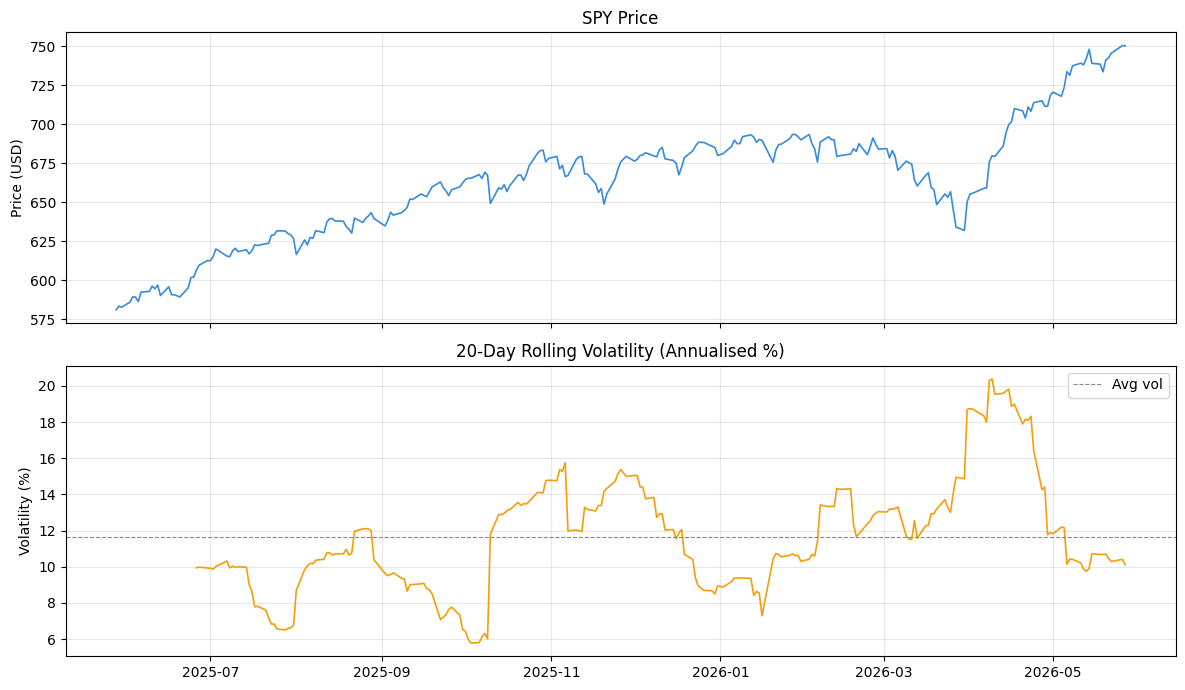

In [3]:
#Rolling volatility shows how risky the market was at each point in time — not just on average. This is far more useful than a single number:
import matplotlib.pyplot as plt

# 20-day rolling volatility (annualised)
rolling_vol = log_returns.rolling(window=20).std() * (252**0.5) * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: price
ax1.plot(spy.index, spy.values, color="#378ADD", linewidth=1.2)
ax1.set_title("SPY Price")
ax1.set_ylabel("Price (USD)")
ax1.grid(alpha=0.3)

# Bottom: rolling volatility
ax2.plot(rolling_vol.index, rolling_vol.values, color="#F59E0B", linewidth=1.2)
ax2.axhline(rolling_vol.mean(), color="#888", linestyle="--", linewidth=0.8, label="Avg vol")
ax2.set_title("20-Day Rolling Volatility (Annualised %)")
ax2.set_ylabel("Volatility (%)")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()
#Look for spikes in volatility — they usually coincide with market selloffs in the price chart above. High vol = fear. Low vol = calm. This relationship is the basis of the VIX index (the 'fear gauge').

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


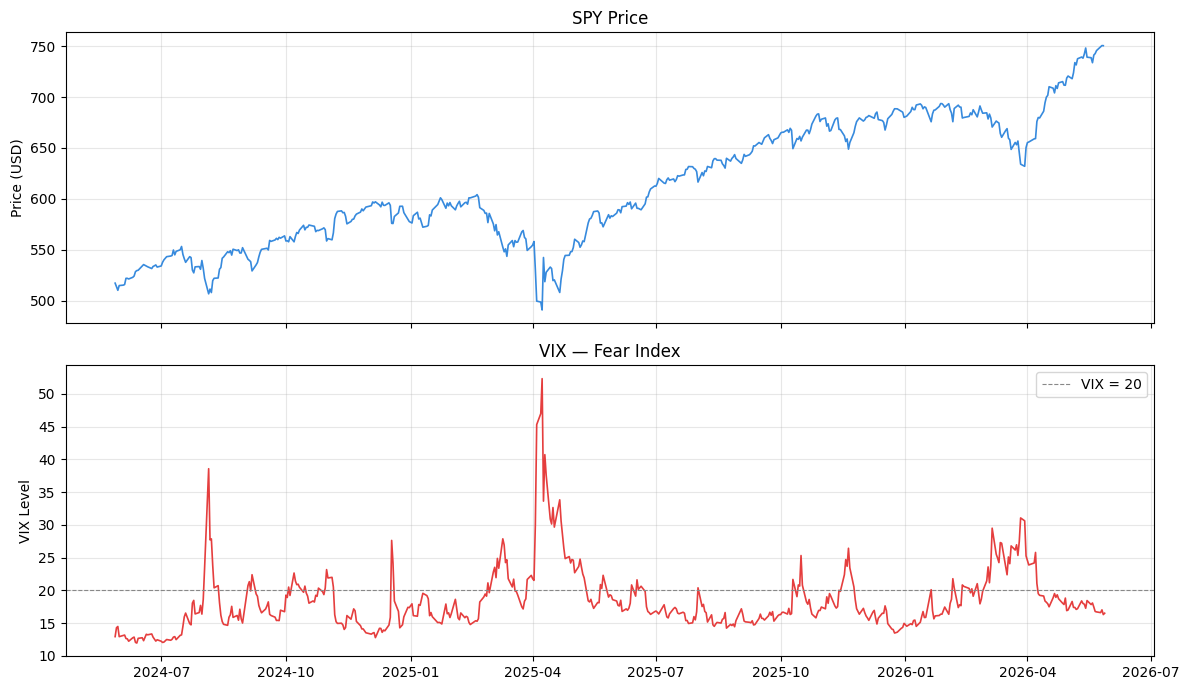

In [4]:
vix = yf.download("^VIX", period="2y")["Close"].squeeze()
spy = yf.download("SPY", period="2y")["Close"].squeeze()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax1.plot(spy.index, spy.values, color="#378ADD", linewidth=1.2)
ax1.set_title("SPY Price")
ax1.set_ylabel("Price (USD)")
ax1.grid(alpha=0.3)

ax2.plot(vix.index, vix.values, color="#E53E3E", linewidth=1.2)
ax2.axhline(20, color="#888", linestyle="--", linewidth=0.8, label="VIX = 20")
ax2.set_title("VIX — Fear Index")
ax2.set_ylabel("VIX Level")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

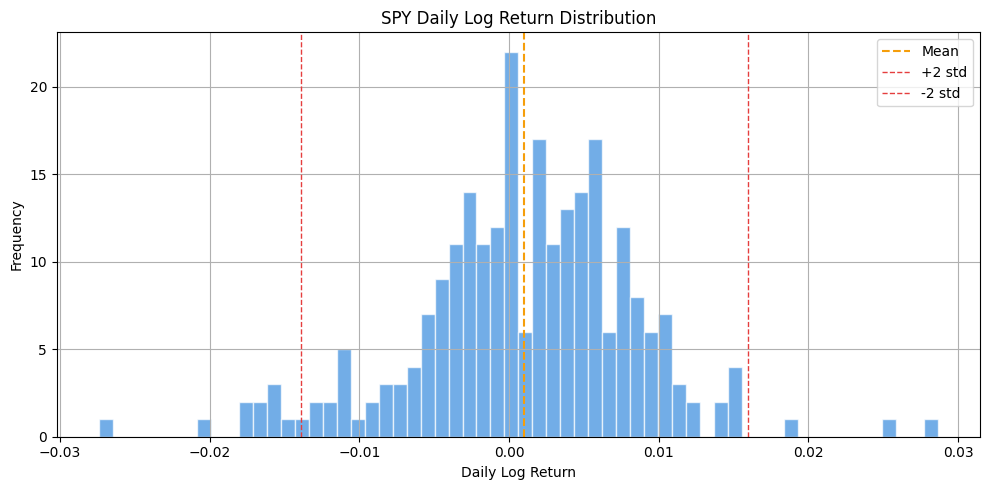

Kurtosis: 1.55
(Normal distribution kurtosis = 0. Higher = fatter tails)


In [5]:
#Plot the distribution of daily returns. This reveals whether returns are normal (bell curve) or have fat tails (more extreme moves than expected):
fig, ax = plt.subplots(figsize=(10, 5))

log_returns.hist(bins=60, ax=ax, color="#378ADD", alpha=0.7, edgecolor="white")
ax.axvline(log_returns.mean(), color="#F59E0B", linestyle="--", linewidth=1.5, label="Mean")
ax.axvline(log_returns.mean() + 2*log_returns.std(), color="#E53E3E", linestyle="--", linewidth=1, label="+2 std")
ax.axvline(log_returns.mean() - 2*log_returns.std(), color="#E53E3E", linestyle="--", linewidth=1, label="-2 std")

ax.set_title("SPY Daily Log Return Distribution")
ax.set_xlabel("Daily Log Return")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.show()

# Check for fat tails
print("Kurtosis:", round(log_returns.kurtosis(), 2))
print("(Normal distribution kurtosis = 0. Higher = fatter tails)")

#If kurtosis > 0, the distribution has fatter tails than a normal curve — extreme moves happen more often than maths assumes. This is why models that assume normality (like basic Sharpe) can underestimate real risk.


In [6]:
#Compute 50-day and 200-day moving averages
#Pull 2 years of data so the 200-day MA has enough history to compute from day one:
spy = yf.download("SPY", period="2y")["Close"].squeeze()

ma50 = spy.rolling(window=50).mean()
ma200 = spy.rolling(window=200).mean()

print("First valid 50-day MA:", ma50.first_valid_index())
print("First valid 200-day MA:", ma200.first_valid_index())
# The 200-day MA needs 200 days of data before it can be computed
# So the first ~200 rows of ma200 will be NaN

[*********************100%***********************]  1 of 1 completed

First valid 50-day MA: 2024-08-07 00:00:00
First valid 200-day MA: 2025-03-14 00:00:00


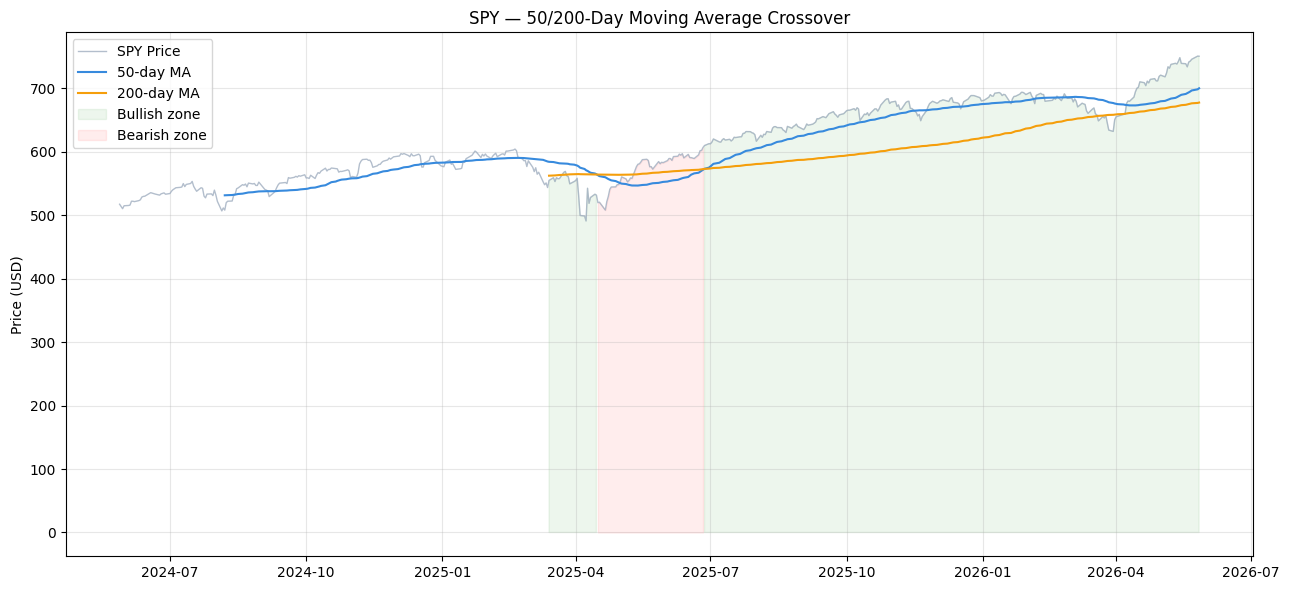

In [7]:
#Plot the crossover chart
fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(spy.index, spy.values, color="#A0AEC0", linewidth=1, label="SPY Price", alpha=0.8)
ax.plot(ma50.index, ma50.values, color="#378ADD", linewidth=1.5, label="50-day MA")
ax.plot(ma200.index, ma200.values, color="#F59E0B", linewidth=1.5, label="200-day MA")

# Shade regions: green when 50 > 200 (bullish), red when 50 < 200 (bearish)
ax.fill_between(spy.index, spy.values, 
    where=(ma50 > ma200), alpha=0.07, color="green", label="Bullish zone")
ax.fill_between(spy.index, spy.values,
    where=(ma50 < ma200), alpha=0.07, color="red", label="Bearish zone")

ax.set_title("SPY — 50/200-Day Moving Average Crossover")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
signals = pd.DataFrame(index=spy.index)
signals["price"] = spy
signals["ma50"] = ma50
signals["ma200"] = ma200

# Signal: 1 when 50MA > 200MA (long), 0 otherwise
signals["signal"] = (signals["ma50"] > signals["ma200"]).astype(int)

# Crossover: where signal changes from 0→1 (golden cross) or 1→0 (death cross)
signals["crossover"] = signals["signal"].diff()

golden = signals[signals["crossover"] == 1]
death  = signals[signals["crossover"] == -1]

print(f"Golden crosses (buy signals): {len(golden)}")
print(f"Death crosses  (sell signals): {len(death)}")
print("Most recent signals:")
print(signals[signals["crossover"] != 0][["price","crossover"]].tail(4))

Golden crosses (buy signals): 2
Death crosses  (sell signals): 1
Most recent signals:
                 price  crossover
Date                             
2024-05-28  517.222412        NaN
2025-03-14  554.762512        1.0
2025-04-16  519.702332       -1.0
2025-06-27  609.738098        1.0


In [11]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download and fully flatten
spy_full = yf.download("SPY", period="1y")
spy_full = spy_full.droplevel(1, axis=1)  # drop the ticker label level

# Confirm columns look right before continuing
print(spy_full.columns.tolist())
# Should print: ['Close', 'High', 'Low', 'Open', 'Volume']

[*********************100%***********************]  1 of 1 completed

['Close', 'High', 'Low', 'Open', 'Volume']


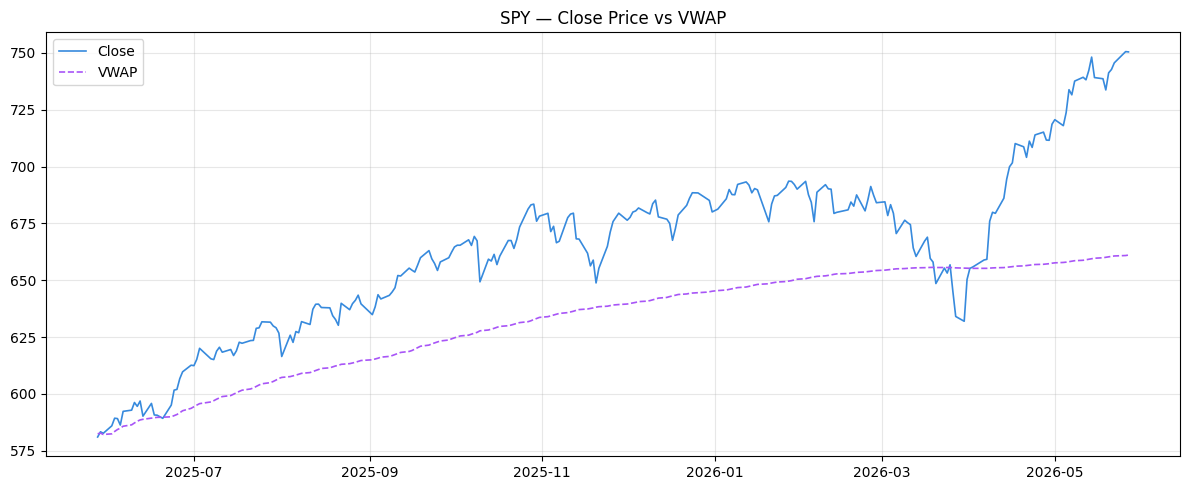

In [12]:
spy_full["typical_price"] = (
    spy_full["High"] + spy_full["Low"] + spy_full["Close"]
) / 3

spy_full["vwap"] = (
    (spy_full["typical_price"] * spy_full["Volume"]).cumsum()
    / spy_full["Volume"].cumsum()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(spy_full.index, spy_full["Close"], label="Close", color="#378ADD", linewidth=1.2)
ax.plot(spy_full.index, spy_full["vwap"], label="VWAP", color="#A855F7", linewidth=1.2, linestyle="--")
ax.set_title("SPY — Close Price vs VWAP")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#When price is above VWAP, the market is trading rich relative to its volume-weighted average. Algo trading desks use VWAP to slice large orders across the day to minimise price impact.

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


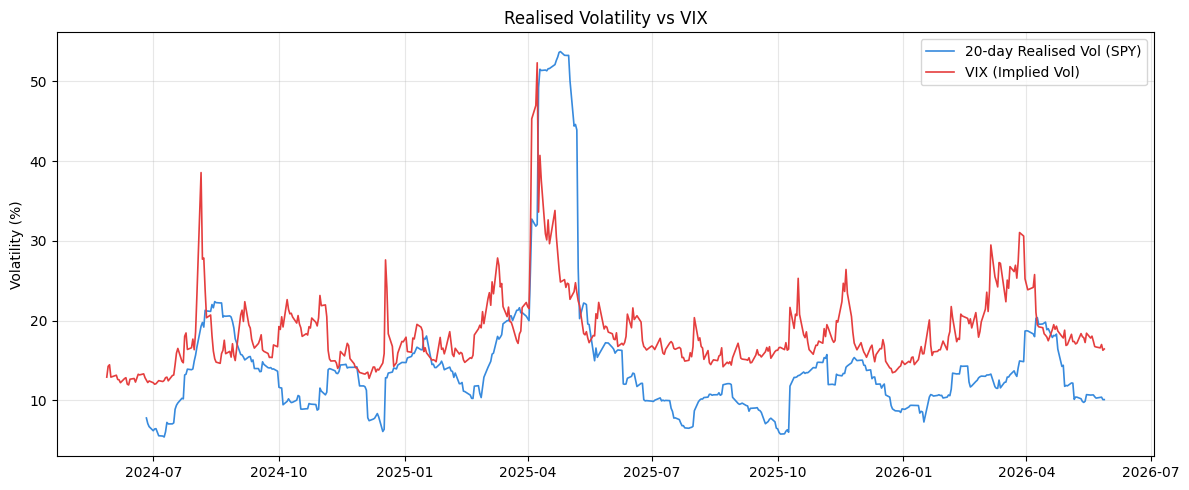

In [13]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

spy = yf.download("SPY", period="2y")["Close"].squeeze()
vix = yf.download("^VIX", period="2y")["Close"].squeeze()

log_returns = np.log(spy / spy.shift(1)).dropna()
rolling_vol = log_returns.rolling(20).std() * np.sqrt(252) * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_vol.index, rolling_vol.values, 
        label="20-day Realised Vol (SPY)", color="#378ADD", linewidth=1.2)
ax.plot(vix.index, vix.values, 
        label="VIX (Implied Vol)", color="#E53E3E", linewidth=1.2)
ax.set_title("Realised Volatility vs VIX")
ax.set_ylabel("Volatility (%)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()